# Evaluate CogVLM on RefOI

This notebook loads our dataset [RefOI](https://huggingface.co/datasets/Seed42Lab/RefOI), evaluates the performance of [CogVLM](https://huggingface.co/THUDM/cogvlm-grounding-generalist-hf) and computes Intersection-over-Union (IoU) and Accuracy.


In [1]:
!pip install torch==2.5.0 torchvision==0.20.1 --index-url https://download.pytorch.org/whl/cu118
!pip install transformers==4.36.2 datasets accelerate evaluate scikit-learn sentencepiece numpy typing-extensions zstandard einops protobuf xformers

Defaulting to user installation because normal site-packages is not writeable
Looking in indexes: https://download.pytorch.org/whl/cu118
ERROR: Could not find a version that satisfies the requirement torch==2.5.0 (from versions: 1.11.0, 1.12.0, 1.12.1, 1.13.0, 1.13.1, 2.0.0, 2.0.1)
ERROR: No matching distribution found for torch==2.5.0
Defaulting to user installation because normal site-packages is not writeable


In [2]:
import os
import json
import sys
import re
import torch
from tqdm import tqdm
from PIL import Image

from transformers import AutoModelForCausalLM, LlamaTokenizer
from datasets import load_dataset

/home/ubuntu/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/ubuntu/.local/lib/python3.10/site-packages/transformers/utils/generic.py:441: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(


In [3]:
# Load the multiple objects of the class
ds_multi = load_dataset("Seed42Lab/RefOI", split="co_occurrence")

print(ds_multi[0].keys())
print(ds_multi[0]['written_descriptions'])
print(ds_multi[0]['spoken_descriptions'])
image = ds_multi[0]['image']
print(round(ds_multi[0]['box_xmin']*1000), round(ds_multi[0]['box_ymin']*1000), round(ds_multi[0]['box_xmax']*1000), round(ds_multi[0]['box_ymax']*1000))

dict_keys(['image', 'mask', 'boxed_image', 'box_xmin', 'box_xmax', 'box_ymin', 'box_ymax', 'is_coco', 'label_name', 'co_occurrence', 'written_descriptions', 'spoken_descriptions'])
['the whale to the right most', 'the whale on the right of the picture', 'the rightmost animal']
['the whale on the right.', 'the whale in the bottom right corner.']
670 633 1000 820


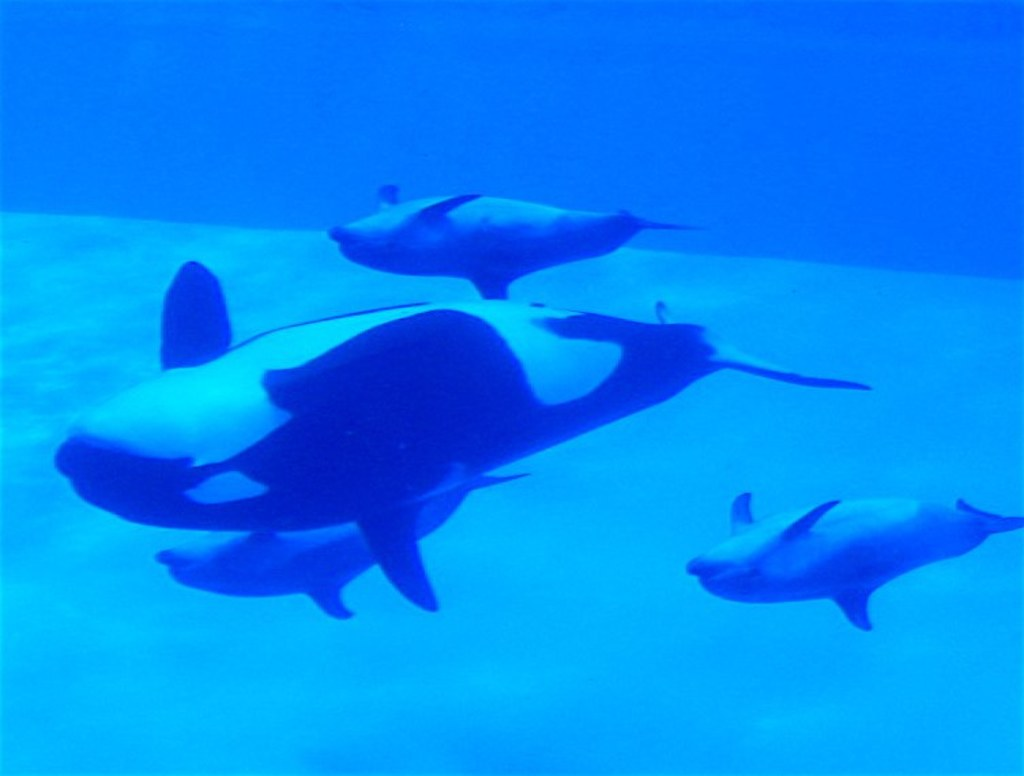

In [4]:
image

In [5]:
def compute_iou(box1, box2):
    """
    Compute the IoU of two boxes. Box format: [x0, y0, x1, y1]
    """
    inter_xmin = max(box1[0], box2[0])
    inter_ymin = max(box1[1], box2[1])
    inter_xmax = min(box1[2], box2[2])
    inter_ymax = min(box1[3], box2[3])
    if inter_xmax < inter_xmin or inter_ymax < inter_ymin:
        return 0.0
    inter_area = (inter_xmax - inter_xmin) * (inter_ymax - inter_ymin)
    box1_area = (box1[2] - box1[0]) * (box1[3] - box1[1])
    box2_area = (box2[2] - box2[0]) * (box2[3] - box2[1])
    union_area = box1_area + box2_area - inter_area
    return inter_area / union_area if union_area > 0 else 0.0

def parse_boxes(text):
    """
    Parse predicted bounding boxes from the generated text.
    Expected format: [[x0,y0,x1,y1]]
    """
    pattern = r"\[\[\s*([\d\.]+)\s*,\s*([\d\.]+)\s*,\s*([\d\.]+)\s*,\s*([\d\.]+)\s*\]\]"
    matches = re.findall(pattern, text)
    boxes = []
    for m in matches:
        box = list(map(float, m))
        boxes.append(box)
    return boxes

def model_inference(image, query):
    """
    Generate output text using the new model, which should contain coordinates in the format [[x0,y0,x1,y1]]
    """
    inputs = model.build_conversation_input_ids(tokenizer, query=query, images=[image])
    inputs = {
        'input_ids': inputs['input_ids'].unsqueeze(0).to('cuda'),
        'token_type_ids': inputs['token_type_ids'].unsqueeze(0).to('cuda'),
        'attention_mask': inputs['attention_mask'].unsqueeze(0).to('cuda'),
        'images': [[inputs['images'][0].to('cuda').to(torch.bfloat16)]],
    }
    gen_kwargs = {"max_length": 2048, "do_sample": False}
    with torch.no_grad():
        outputs = model.generate(**inputs, **gen_kwargs)
        outputs = outputs[:, inputs['input_ids'].shape[1]:]
        decoded = tokenizer.decode(outputs[0])
    return decoded

def model_reg(data_item):
    image = data_item['image'].convert('RGB')
    query = f"Describe the object in the [[{round(data_item['box_xmin']*1000)},{round(data_item['box_ymin']*1000)},{round(data_item['box_xmax']*1000)},{round(data_item['box_ymax']*1000)}]] in a way that allows another person to distinguish it from all other objects in the image."
    output_text = model_inference(image, query)
    return output_text
    
def eval_iter(data_item, verbose=True):

    # Groundtruth box (assumed to be in normalized coordinates)
    gt_box = [
        data_item.get("box_xmin")*1000,
        data_item.get("box_ymin")*1000,
        data_item.get("box_xmax")*1000,
        data_item.get("box_ymax")*1000
    ]

    description = model_reg(data_item)
    if verbose:
        print('\n', description)
        print('Ground Truth:', gt_box)

    query = (f"{description[-1]}. Please provide the bounding box in the format [[x0,y0,x1,y1]] for this mentioned object in the image.")
    image = data_item['image'].convert('RGB')
    output_text = model_inference(image, query)
    pred_boxes = parse_boxes(output_text)
    
    print('Prediction:', pred_boxes)
    
    if not pred_boxes:
        if verbose:
            print(f"No predicted box parsed from model output, output: {output_text}")
            print('IoU: 0.0')
        max_iou = 0.0
        acc = 0
    else:
        # Compute IoU between groundtruth and all predicted boxes, take the maximum
        ious = [compute_iou(gt_box, pb) for pb in pred_boxes]
        max_iou = max(ious)
        acc = 1 if max_iou >= 0.5 else 0
    if verbose:
        print('IoU:', max_iou)

    return {
        "image_id": data_item.get("image_id"),
        "gt_box": gt_box,
        "pred_boxes": pred_boxes,
        "max_iou": max_iou,
        "acc@0.5": acc
    }

In [6]:
tokenizer = LlamaTokenizer.from_pretrained('lmsys/vicuna-7b-v1.5')
model = AutoModelForCausalLM.from_pretrained(
    'THUDM/cogvlm-grounding-generalist-hf',
    torch_dtype=torch.bfloat16,
    low_cpu_mem_usage=True,
    trust_remote_code=True,
    device_map='balanced'
).eval()

/home/ubuntu/.local/lib/python3.10/site-packages/huggingface_hub/file_download.py:896: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/home/ubuntu/.local/lib/python3.10/site-packages/transformers/utils/generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
/home/ubuntu/.local/lib/python3.10/site-packages/transformers/utils/generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
Loading checkpoint shards: 100%|██████████| 8/8 [00:07<00:00,  1.01it/s]
/home/ubuntu/.local/lib/python3.10/site-packages/huggingface_hub/file_download.py:896: FutureWarning: `resume_downl

In [ ]:
all_results = []
total_iou = 0.0
total_acc = 0
count = 0

# for data_item in tqdm(ds_multi, desc="Evaluating"):
for data_item in ds_multi:
    result = eval_iter(data_item)
    if result is None:
        continue
    all_results.append(result)
    total_iou += result["max_iou"]
    total_acc += result["acc@0.5"]
    count += 1

avg_iou = total_iou / count if count > 0 else 0.0
avg_acc = total_acc / count if count > 0 else 0.0

print("Evaluation complete!")
print(f"Average IoU: {avg_iou:.4f}")
print(f"Acc@0.5: {avg_acc:.4f}")


 The dolphin is gray</s>
Ground Truth: [669.811, 632.78, 1000.0, 819.502]
Prediction: []
No predicted box parsed from model output, output: Three dolphins [[052,328,862,794;316,226,692,388;668,630,997,816]] swimming in the ocean.</s>
IoU: 0.0
IoU: 0.0

 A black and white whale</s>
Ground Truth: [48.742, 338.174, 850.629, 782.158]
Prediction: []
No predicted box parsed from model output, output: Three dolphins [[052,328,862,794;316,226,692,388;668,630,997,816]] swimming in the ocean.</s>
IoU: 0.0
IoU: 0.0

 The dolphin is in the water</s>
Ground Truth: [339.752, 149.644, 482.80600000000004, 258.907]
Prediction: []
No predicted box parsed from model output, output: Two dolphins [[202,451,911,654;338,143,488,266]] swimming in the ocean.</s>
IoU: 0.0
IoU: 0.0

 A dolphin's tail</s>
Ground Truth: [790.614, 375.45099999999996, 1000.0, 555.957]
